# Лабораторная 4. Моделирование Винеровского случайного процесса.

## 1. Определение Винеровского случайного процесса.

Винеровским процессом, выходящим из нуля, называется случайный процесс $w(t), t \in T = [0, \inf)$, обладающий следующими свойствами:

1. $w(0)=0$ п.н.;
2. $\forall 0 \le t_0 < t_1 < \dots < t_n$ СВ $w(t_1) - w(t_0), w(t_2) - w(t_1), \dots, w(t_n) - w(t_{n-1})$ независимы в совокупности;
3. СВ $w(t) - w(s), 0 \le s \le t$ имеет нормальное распределение $\mathcal{N}(0, \sigma^2(t-s))$.

In [45]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Алгоритм моделирования

$T$ - конечное время, $N$ - шаг, $\sigma$ - коэффициент диффузии, $\Delta t = T/N$
1. Генерируем $N$ случайных величин, имеющих распределение $\mathcal{N}(0, \sigma^2 \cdot \Delta t)$;
2. Заменяем первую случайную величину на 0;
3. Считаем кумулянтную сумму случайных величин;

И так для каждого пути.

In [46]:
def simulate_wiener_process(T=1, N=1000, n_paths=1, diffusion=1, seed=42):
    dt = T / N
    np.random.seed(seed)
    random_variables = np.random.normal(0, np.sqrt(diffusion*dt), size=(n_paths, N))
    random_variables[:, 0] = 0

    process = np.cumsum(random_variables, axis=1)
    time_net = np.linspace(0, T, N)
    return time_net, process

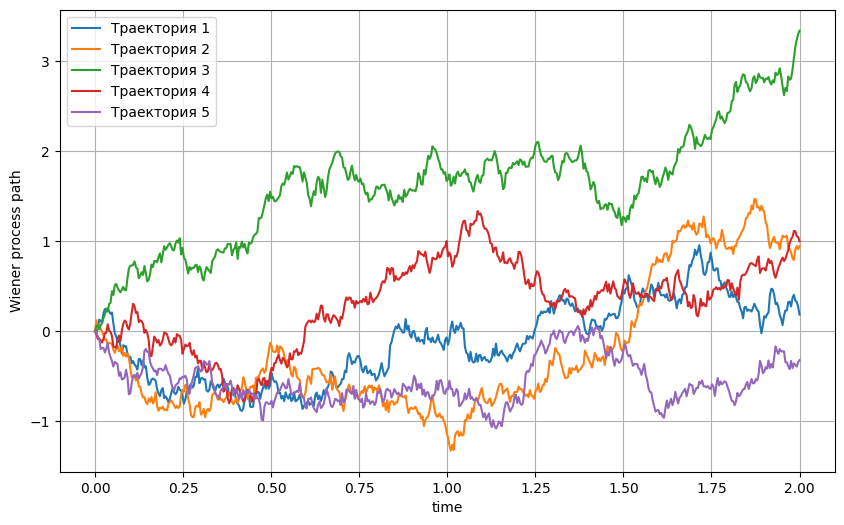

In [49]:
t, w = simulate_wiener_process(T=2, N=500, n_paths=5, seed=42, diffusion=1)

plt.figure(figsize=(10, 6))
for i in range(w.shape[0]):
    plt.plot(t, w[i], label=f'Траектория {i+1}')

plt.xlabel('time')
plt.ylabel('Wiener process path')
plt.grid()
plt.legend()
plt.show()